# 08 — Huấn luyện, tuning và so sánh mô hình

**Người phụ trách:** Bùi Đức Mạnh — Modeling & Evaluation Lead

Notebook này sử dụng nguyên trạng hai split đã bàn giao (`model_train_raw.csv`, `model_test_raw.csv`). Mọi imputation, scaling và encoding đều nằm trong `build_model_pipeline` để được fit riêng trong từng fold. Tuning và lựa chọn chỉ dùng train/CV; holdout test chỉ được mở ở bước đánh giá cuối.

Target là `price_per_m2` (VNĐ/m²). Biến thể Ridge log-transform dùng `TransformedTargetRegressor` để tự đảo `expm1`, vì vậy mọi MAE/RMSE/R² dưới đây đều ở thang giá gốc. Không loại các dòng target cực trị đã được giữ trong data contract.

In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, KFold, cross_validate, learning_curve,
)

warnings.filterwarnings('default')
RANDOM_STATE = 42
here = Path.cwd().resolve()
project_root = here.parent if here.name == 'notebooks' else here
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.preprocess import MODEL_FEATURES, TARGET, build_model_pipeline

DATA_DIR = project_root / 'data' / 'processed'
REPORTS_DIR = project_root / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
MODELS_DIR = project_root / 'models'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Python: {sys.version.split()[0]} | scikit-learn: {sklearn.__version__}')
print('Features:', MODEL_FEATURES)

Project root: D:\Study\LapTrinhPhanTichDuLieu\Final_Project_Nhom_22-24-main
Python: 3.13.9 | scikit-learn: 1.7.2
Features: ['dien_tich_goc', 'so_phong_ngu', 'khu_vuc_nhom', 'loai_bds']


## 1. Nạp tập train và xác nhận data contract

Chỉ đọc file train ở giai đoạn này. Test được giữ nguyên trạng và chưa được nạp hay dùng để chọn mô hình. Các cột `gia_goc`, `link_nguon` và target không được đưa vào ma trận X.

In [2]:
train_path = DATA_DIR / 'model_train_raw.csv'
try:
    train_df = pd.read_csv(train_path, encoding='utf-8-sig')
except (OSError, pd.errors.ParserError, UnicodeError) as exc:
    raise RuntimeError(f'Không đọc được tập train: {train_path}') from exc

required_columns = set(MODEL_FEATURES + [TARGET, 'link_nguon'])
missing_columns = sorted(required_columns - set(train_df.columns))
if missing_columns:
    raise ValueError(f'Tập train thiếu cột bắt buộc: {missing_columns}')

X_train = train_df[MODEL_FEATURES].copy()
y_train = pd.to_numeric(train_df[TARGET], errors='raise').copy()
if not y_train.gt(0).all() or not np.isfinite(y_train).all():
    raise ValueError('Target train phải dương và hữu hạn.')
if set(X_train.columns) != set(MODEL_FEATURES):
    raise AssertionError('Feature train không khớp feature contract.')
if {'gia', 'gia_goc', TARGET} & set(X_train.columns):
    raise AssertionError('Phát hiện cột gây target leakage trong X_train.')

print(f'Train: {X_train.shape[0]:,} dòng; {X_train.shape[1]} feature')
print('Target (VNĐ/m²):')
display(y_train.describe(percentiles=[0.01, 0.5, 0.99]).to_frame().T)

Train: 2,784 dòng; 4 feature
Target (VNĐ/m²):


,count,mean,std,min,1%,50%,99%,max
price_per_m2,2784.0,1.189386e+08,9.068220e+07,0.010579,4.388667e+06,100000000.0,4.630769e+08,8.055556e+08


## 2. Huấn luyện và tuning trên train

So sánh bốn cấu hình: LinearRegression baseline, Ridge trên target gốc, Ridge trên `log1p(target)`, và RandomForest. GridSearchCV tối ưu MAE với 5-fold KFold shuffle cố định. Cả preprocessing lẫn estimator đều được fit trong Pipeline ở từng fold; test không tham gia tìm siêu tham số.

In [3]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
alpha_grid = np.logspace(-3, 3, 13)

model_specs = {
    'LinearRegression': {
        'estimator': build_model_pipeline(LinearRegression()),
        'params': None,
    },
    'Ridge': {
        'estimator': build_model_pipeline(Ridge()),
        'params': {'model__alpha': alpha_grid},
    },
    'Ridge_log1p': {
        'estimator': build_model_pipeline(Ridge(), log_target=True),
        'params': {'regressor__model__alpha': alpha_grid},
    },
    'RandomForest': {
        'estimator': build_model_pipeline(
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
        ),
        'params': {
            'model__n_estimators': [200, 400],
            'model__max_features': ['sqrt', 1.0],
            'model__min_samples_leaf': [1, 3],
        },
    },
}

fitted_models = {}
searches = {}
for model_name, spec in model_specs.items():
    print(f'Đang fit: {model_name}')
    if spec['params'] is None:
        estimator = spec['estimator']
        estimator.fit(X_train, y_train)
        fitted_models[model_name] = estimator
    else:
        search = GridSearchCV(
            estimator=spec['estimator'],
            param_grid=spec['params'],
            scoring='neg_mean_absolute_error',
            cv=cv,
            refit=True,
            n_jobs=-1,
            return_train_score=False,
            error_score='raise',
        )
        search.fit(X_train, y_train)
        searches[model_name] = search
        fitted_models[model_name] = search.best_estimator_
        print(f'  Best CV MAE: {-search.best_score_:,.0f} VNĐ/m²')
        print(f'  Best params: {search.best_params_}')

print('Hoàn tất tuning; mọi best_estimator_ đã được refit trên toàn bộ train.')

Đang fit: LinearRegression
Đang fit: Ridge
  Best CV MAE: 56,624,051 VNĐ/m²
  Best params: {'model__alpha': np.float64(10.0)}
Đang fit: Ridge_log1p
  Best CV MAE: 54,035,249 VNĐ/m²
  Best params: {'regressor__model__alpha': np.float64(3.1622776601683795)}
Đang fit: RandomForest
  Best CV MAE: 51,674,711 VNĐ/m²
  Best params: {'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Hoàn tất tuning; mọi best_estimator_ đã được refit trên toàn bộ train.


## 3. Cross-validation và quy tắc chọn mô hình

Tính MAE, RMSE, R² cho từng fold bằng các estimator đã tune. Quy tắc one-standard-error chọn mô hình đơn giản nhất có CV MAE nằm trong một sai số chuẩn của mô hình tốt nhất. Thứ tự độ phức tạp được khai báo rõ: LinearRegression, Ridge, Ridge_log1p, RandomForest. Việc chọn hoàn tất trước khi nạp test.

In [4]:
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}
cv_results = {}
for model_name, estimator in fitted_models.items():
    fold_scores = cross_validate(
        estimator, X_train, y_train, cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=False,
    )
    cv_results[model_name] = {
        'mae_folds': -fold_scores['test_mae'],
        'rmse_folds': -fold_scores['test_rmse'],
        'r2_folds': fold_scores['test_r2'],
    }

cv_summary_rows = []
for model_name, folds in cv_results.items():
    cv_summary_rows.append({
        'model': model_name,
        'cv_mae_mean': float(np.mean(folds['mae_folds'])),
        'cv_mae_std': float(np.std(folds['mae_folds'], ddof=1)),
        'cv_mae_se': float(np.std(folds['mae_folds'], ddof=1) / np.sqrt(len(folds['mae_folds']))),
        'cv_rmse_mean': float(np.mean(folds['rmse_folds'])),
        'cv_rmse_std': float(np.std(folds['rmse_folds'], ddof=1)),
        'cv_r2_mean': float(np.mean(folds['r2_folds'])),
        'cv_r2_std': float(np.std(folds['r2_folds'], ddof=1)),
    })
cv_summary = pd.DataFrame(cv_summary_rows).set_index('model')
best_cv_name = cv_summary['cv_mae_mean'].idxmin()
selection_threshold = (
    cv_summary.loc[best_cv_name, 'cv_mae_mean']
    + cv_summary.loc[best_cv_name, 'cv_mae_se']
)
eligible = cv_summary[cv_summary['cv_mae_mean'] <= selection_threshold].index.tolist()
simplicity_order = ['LinearRegression', 'Ridge', 'Ridge_log1p', 'RandomForest']
selected_model_name = next(name for name in simplicity_order if name in eligible)
selected_model = fitted_models[selected_model_name]

train_metric_rows = []
for model_name, estimator in fitted_models.items():
    predictions = estimator.predict(X_train)
    train_metric_rows.append({
        'model': model_name,
        'train_mae': mean_absolute_error(y_train, predictions),
        'train_rmse': mean_squared_error(y_train, predictions) ** 0.5,
        'train_r2': r2_score(y_train, predictions),
    })
train_summary = pd.DataFrame(train_metric_rows).set_index('model')

display(cv_summary.style.format('{:,.4f}'))
print(f'Mô hình có CV MAE thấp nhất: {best_cv_name}')
print(f'Ngưỡng one-standard-error: {selection_threshold:,.0f} VNĐ/m²')
print(f'Mô hình được chọn trước khi mở test: {selected_model_name}')

,cv_mae_mean,cv_mae_std,cv_mae_se,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
model,,,,,,,
LinearRegression,"56,640,471.2476","1,617,001.8640","723,145.2175","79,947,198.8408","3,121,606.5537",0.2209,0.0202
Ridge,"56,624,051.3716","1,595,765.9831","713,648.2429","79,963,698.9690","3,121,698.9063",0.2206,0.0200
Ridge_log1p,"54,035,249.1395","1,563,417.9332","699,181.7552","83,007,842.8984","3,865,278.8366",0.1602,0.0353
RandomForest,"51,674,711.1279","1,584,750.5316","708,721.9832","76,954,544.4128","2,982,354.7891",0.2776,0.0344


Mô hình có CV MAE thấp nhất: RandomForest
Ngưỡng one-standard-error: 52,383,433 VNĐ/m²
Mô hình được chọn trước khi mở test: RandomForest


## 4. Đánh giá holdout cuối cùng và xuất bảng bàn giao

CV đã quyết định mô hình trước khi dùng test. Tại bước cuối này, test được đọc một lần để báo cáo chỉ số của các ứng viên đã khóa; kết quả test không được dùng để đổi siêu tham số hay lựa chọn lại mô hình.

In [5]:
test_path = DATA_DIR / 'model_test_raw.csv'
try:
    test_df = pd.read_csv(test_path, encoding='utf-8-sig')
except (OSError, pd.errors.ParserError, UnicodeError) as exc:
    raise RuntimeError(f'Không đọc được tập test: {test_path}') from exc

missing_test_columns = sorted(required_columns - set(test_df.columns))
if missing_test_columns:
    raise ValueError(f'Tập test thiếu cột bắt buộc: {missing_test_columns}')
if set(train_df['link_nguon']) & set(test_df['link_nguon']):
    raise AssertionError('Phát hiện link_nguon trùng giữa train và test.')
X_test = test_df[MODEL_FEATURES].copy()
y_test = pd.to_numeric(test_df[TARGET], errors='raise').copy()
if not y_test.gt(0).all() or not np.isfinite(y_test).all():
    raise ValueError('Target test phải dương và hữu hạn.')

test_metric_rows = []
for model_name, estimator in fitted_models.items():
    predictions = estimator.predict(X_test)
    test_metric_rows.append({
        'model': model_name,
        'test_mae': mean_absolute_error(y_test, predictions),
        'test_rmse': mean_squared_error(y_test, predictions) ** 0.5,
        'test_r2': r2_score(y_test, predictions),
    })
test_summary = pd.DataFrame(test_metric_rows).set_index('model')
comparison = train_summary.join(cv_summary).join(test_summary)
comparison['train_cv_mae_gap'] = comparison['cv_mae_mean'] - comparison['train_mae']
comparison['train_cv_mae_gap_pct'] = (
    comparison['train_cv_mae_gap'] / comparison['cv_mae_mean'] * 100
)
comparison['selected_by_cv'] = comparison.index == selected_model_name
comparison = comparison.reset_index()

comparison_path = REPORTS_DIR / 'model_comparison.csv'
try:
    comparison.to_csv(comparison_path, index=False, encoding='utf-8-sig')
except OSError as exc:
    raise RuntimeError(f'Không lưu được bảng so sánh: {comparison_path}') from exc

hyperparameter_rows = [{'model': 'LinearRegression', 'best_params': '{}'}]
for model_name, search in searches.items():
    hyperparameter_rows.append({
        'model': model_name,
        'best_params': json.dumps(search.best_params_, ensure_ascii=False, default=str),
        'best_cv_mae_vnd_m2': -search.best_score_,
    })
hyperparameters = pd.DataFrame(hyperparameter_rows)
hyperparameters_path = REPORTS_DIR / 'model_hyperparameters.csv'
try:
    hyperparameters.to_csv(hyperparameters_path, index=False, encoding='utf-8-sig')
except OSError as exc:
    raise RuntimeError(f'Không lưu được bảng siêu tham số: {hyperparameters_path}') from exc

best_model_path = MODELS_DIR / 'best_model.joblib'
try:
    joblib.dump(selected_model, best_model_path)
except (OSError, ValueError) as exc:
    raise RuntimeError(f'Không lưu được pipeline tốt nhất: {best_model_path}') from exc

display(comparison.style.format({
    column: '{:,.3f}' for column in comparison.select_dtypes(include='number').columns
}))
display(hyperparameters)
print(f'Đã lưu: {comparison_path.relative_to(project_root)}')
print(f'Đã lưu: {hyperparameters_path.relative_to(project_root)}')
print(f'Đã lưu pipeline: {best_model_path.relative_to(project_root)}')

,model,train_mae,train_rmse,train_r2,cv_mae_mean,cv_mae_std,cv_mae_se,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_mae,test_rmse,test_r2,train_cv_mae_gap,train_cv_mae_gap_pct,selected_by_cv
0,LinearRegression,"56,514,732.853","79,861,907.776",0.224,"56,640,471.248","1,617,001.864","723,145.218","79,947,198.841","3,121,606.554",0.221,0.020,"56,064,054.504","81,341,796.023",0.241,"125,738.394",0.222,False
1,Ridge,"56,499,335.742","79,876,407.340",0.224,"56,624,051.372","1,595,765.983","713,648.243","79,963,698.969","3,121,698.906",0.221,0.020,"56,112,214.236","81,419,415.910",0.240,"124,715.630",0.220,False
2,Ridge_log1p,"53,822,729.228","82,844,863.813",0.165,"54,035,249.140","1,563,417.933","699,181.755","83,007,842.898","3,865,278.837",0.160,0.035,"55,411,119.582","85,023,829.217",0.171,"212,519.911",0.393,False
3,RandomForest,"44,406,079.942","67,167,415.480",0.451,"51,674,711.128","1,584,750.532","708,721.983","76,954,544.413","2,982,354.789",0.278,0.034,"53,819,303.445","81,016,230.092",0.247,"7,268,631.186",14.066,True


,model,best_params,best_cv_mae_vnd_m2
0,LinearRegression,{},NaN
1,Ridge,"{""model__alpha"": 10.0}",5.662405e+07
2,Ridge_log1p,"{""regressor__model__alpha"": 3.1622776601683795}",5.403525e+07
3,RandomForest,"{""model__max_features"": ""sqrt"", ""model__min_sa...",5.167471e+07


Đã lưu: reports\model_comparison.csv
Đã lưu: reports\model_hyperparameters.csv
Đã lưu pipeline: models\best_model.joblib


## 5. Learning curve và residual analysis

Learning curve được tính bằng CV trên train với MAE gốc để chẩn đoán bias/variance. Residuals được phân tích trên holdout sau khi lựa chọn mô hình; đây là báo cáo cuối, không dùng để điều chỉnh mô hình. Residual dương nghĩa là giá thực tế cao hơn dự đoán.

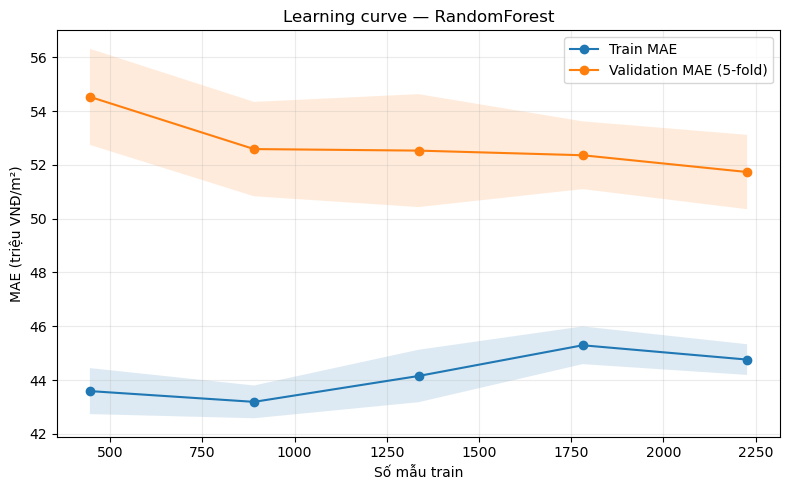

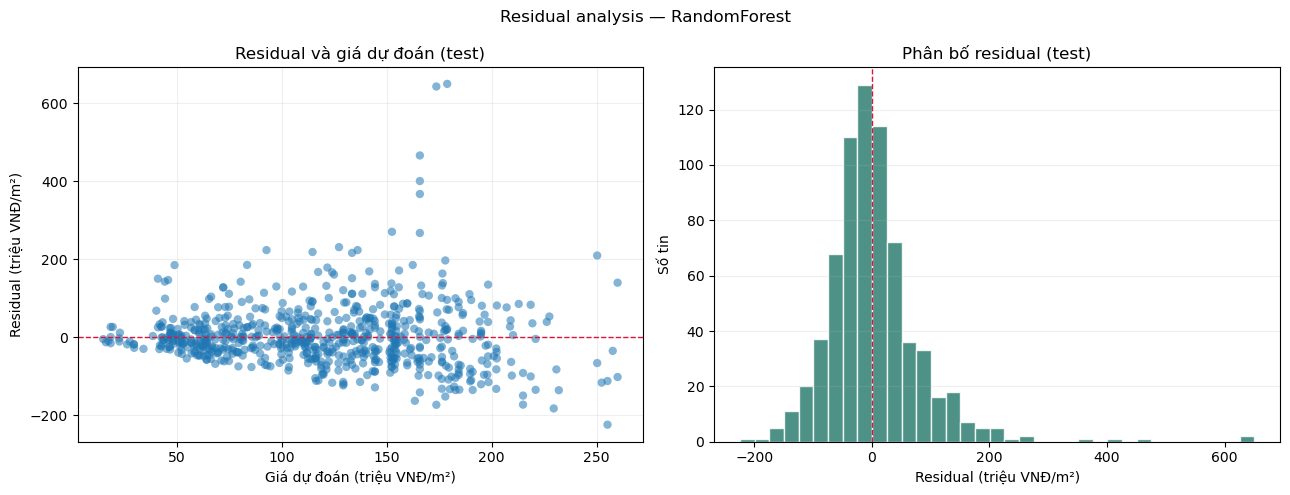

Đã lưu: reports\figures\learning_curve_best_model.png
Đã lưu: reports\figures\residual_analysis_best_model.png


In [6]:
train_sizes, train_scores, validation_scores = learning_curve(
    selected_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
train_mae_curve = -train_scores
validation_mae_curve = -validation_scores

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mae_curve.mean(axis=1) / 1e6, marker='o', label='Train MAE')
ax.fill_between(
    train_sizes,
    (train_mae_curve.mean(axis=1) - train_mae_curve.std(axis=1)) / 1e6,
    (train_mae_curve.mean(axis=1) + train_mae_curve.std(axis=1)) / 1e6,
    alpha=0.15,
)
ax.plot(train_sizes, validation_mae_curve.mean(axis=1) / 1e6, marker='o', label='Validation MAE (5-fold)')
ax.fill_between(
    train_sizes,
    (validation_mae_curve.mean(axis=1) - validation_mae_curve.std(axis=1)) / 1e6,
    (validation_mae_curve.mean(axis=1) + validation_mae_curve.std(axis=1)) / 1e6,
    alpha=0.15,
)
ax.set(title=f'Learning curve — {selected_model_name}', xlabel='Số mẫu train', ylabel='MAE (triệu VNĐ/m²)')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
learning_curve_path = FIGURES_DIR / 'learning_curve_best_model.png'
try:
    fig.savefig(learning_curve_path, dpi=160, bbox_inches='tight')
except OSError as exc:
    raise RuntimeError(f'Không lưu được learning curve: {learning_curve_path}') from exc
plt.show()

best_test_predictions = selected_model.predict(X_test)
residuals = y_test.to_numpy() - best_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(best_test_predictions / 1e6, residuals / 1e6, alpha=0.55, edgecolors='none')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1)
axes[0].set(title='Residual và giá dự đoán (test)', xlabel='Giá dự đoán (triệu VNĐ/m²)', ylabel='Residual (triệu VNĐ/m²)')
axes[0].grid(alpha=0.2)
axes[1].hist(residuals / 1e6, bins=35, color='#2f7f72', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1)
axes[1].set(title='Phân bố residual (test)', xlabel='Residual (triệu VNĐ/m²)', ylabel='Số tin')
axes[1].grid(axis='y', alpha=0.2)
fig.suptitle(f'Residual analysis — {selected_model_name}')
fig.tight_layout()
residual_path = FIGURES_DIR / 'residual_analysis_best_model.png'
try:
    fig.savefig(residual_path, dpi=160, bbox_inches='tight')
except OSError as exc:
    raise RuntimeError(f'Không lưu được residual plot: {residual_path}') from exc
plt.show()
print(f'Đã lưu: {learning_curve_path.relative_to(project_root)}')
print(f'Đã lưu: {residual_path.relative_to(project_root)}')

## 6. Nhận xét và giới hạn diễn giải

Ưu tiên mô hình có MAE cross-validation thấp nhưng không phức tạp hơn cần thiết: one-standard-error rule tránh chọn RandomForest chỉ vì một chênh lệch CV nhỏ có thể nằm trong nhiễu lấy mẫu. Khoảng cách train–CV MAE giúp nhận diện dấu hiệu overfitting; learning curve cho biết khoảng cách này có thu hẹp khi tăng dữ liệu hay không. Ridge kiểm soát hệ số tuyến tính bằng regularization, còn biến thể `log1p` giảm ảnh hưởng của phân phối target lệch phải và đã được inverse-transform trước khi tính metric.

Residual phân tán không có xu hướng rõ quanh 0 là dấu hiệu phù hợp hơn; hình phễu hoặc cụm lệch cho thấy phương sai không đồng nhất hay nhóm bất động sản chưa được mô tả đủ. Đây là chẩn đoán, không phải bằng chứng nhân quả. R², MAE và RMSE chịu ảnh hưởng của mức giá và các quan sát cực trị; không nên đối chiếu trực tiếp với dự án khác nếu khác scope hoặc cách lập target.

**Bàn giao:** `reports/model_comparison.csv`, `reports/model_hyperparameters.csv`, `models/best_model.joblib`, và hai biểu đồ trong `reports/figures/`. Pipeline joblib nhận DataFrame đầu vào với đúng bốn cột feature theo feature contract.